# Adaptive feature fusion for SMS spam classification


In [1]:
!pip -q install datasets transformers gensim scikit-learn pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 27.8 MB/s eta 0:00:00


In [2]:
import re
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from datasets import load_dataset
from gensim.downloader import load as gensim_load
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## Dataset and fixed splits

The code loads `ucirvine/sms_spam` from Hugging Face, a distribution of SMS Spam Collection [1,10,11]. The saved run contains 5,574 rows with 0=ham and 1=spam. Do not substitute a different row-count variant. Lowercasing and whitespace normalization precede two stratified splits using seed 42. Saved sizes are 3,901 / 836 / 837.

No deduplication or group-aware split is implemented. Ten duplicate rows beyond their first occurrence are confirmed in the supplied test CSV. Training/development texts and original split IDs were not supplied, so cross-split exact/near-duplicate overlap is unresolved. Test inspection during historical tuning cannot be reconstructed. Preprocessing fitting below uses training only.


In [9]:
!pip -q install -U datasets huggingface_hub

from datasets import load_dataset

dataset = load_dataset("ucirvine/sms_spam", split="train")
df = dataset.to_pandas()[["sms", "label"]].rename(columns={"sms": "text"})

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.9/842.9 kB 19.4 MB/s eta 0:00:00


README.md:   0%|          | 0.00/4.98k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  359kB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5574 [00:00<?, ? examples/s]

In [10]:
def clean_text(text):
    text = str(text).lower()
    return re.sub(r"\s+", " ", text).strip()

df["clean_text"] = df["text"].apply(clean_text)

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)

dev_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

train_df = train_df.reset_index(drop=True)
dev_df = dev_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape, "Dev:", dev_df.shape, "Test:", test_df.shape)
print(train_df["label"].value_counts().rename({0: "ham", 1: "spam"}))

Train: (3901, 3) Dev: (836, 3) Test: (837, 3)
label
ham     3378
spam     523
Name: count, dtype: int64


## Feature extraction

TF-IDF uses lexical unigrams/bigrams, a maximum of 5,000 features, min_df=2 and sublinear term frequency [2]. GloVe uses pretrained 100-dimensional Wikipedia/Gigaword vectors [3,13], averages in-vocabulary regex tokens, drops unknown words, and returns zero when none are known. The zero vector can become nonzero after training-fitted standardization.

`distilbert-base-uncased` supplies contextual features [4,12]. The attention-mask mean excludes padding but includes special tokens. Input length is capped at 128 tokenizer tokens. All encoder parameters are frozen and dropout is disabled during extraction. Internal `bert` names are historical identifiers referring to DistilBERT. Every message requires extraction, irrespective of the learned gate.


In [11]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_tfidf_train = tfidf.fit_transform(train_df["clean_text"])
X_tfidf_dev = tfidf.transform(dev_df["clean_text"])
X_tfidf_test = tfidf.transform(test_df["clean_text"])

print("TF-IDF dimension:", X_tfidf_train.shape[1])

TF-IDF dimension: 5000


In [12]:
glove = gensim_load("glove-wiki-gigaword-100")
STATIC_DIM = 100

def mean_glove_embedding(text):
    tokens = re.findall(r"\b\w+\b", text.lower())
    vectors = [glove[token] for token in tokens if token in glove.key_to_index]
    if not vectors:
        return np.zeros(STATIC_DIM, dtype=np.float32)
    return np.mean(vectors, axis=0).astype(np.float32)

X_static_train = np.vstack(train_df["clean_text"].apply(mean_glove_embedding))
X_static_dev = np.vstack(dev_df["clean_text"].apply(mean_glove_embedding))
X_static_test = np.vstack(test_df["clean_text"].apply(mean_glove_embedding))

static_scaler = StandardScaler()
X_static_train = static_scaler.fit_transform(X_static_train).astype(np.float32)
X_static_dev = static_scaler.transform(X_static_dev).astype(np.float32)
X_static_test = static_scaler.transform(X_static_test).astype(np.float32)

print("Static embedding dimension:", X_static_train.shape[1])

[==================================================] 100.0% 128.1/128.1MB downloaded
Static embedding dimension: 100


In [13]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert = AutoModel.from_pretrained(MODEL_NAME).to(device)
bert.eval()
for parameter in bert.parameters():
    parameter.requires_grad = False

BERT_DIM = bert.config.hidden_size

@torch.no_grad()
def get_bert_embeddings(texts, batch_size=32, max_length=128):
    embeddings = []
    for start in range(0, len(texts), batch_size):
        batch_texts = texts.iloc[start:start + batch_size].tolist()
        encoded = tokenizer(
            batch_texts, padding=True, truncation=True,
            max_length=max_length, return_tensors="pt"
        ).to(device)
        outputs = bert(**encoded).last_hidden_state
        mask = encoded["attention_mask"].unsqueeze(-1)
        pooled = (outputs * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        embeddings.append(pooled.cpu().numpy())
    return np.vstack(embeddings).astype(np.float32)

X_bert_train = get_bert_embeddings(train_df["clean_text"])
X_bert_dev = get_bert_embeddings(dev_df["clean_text"])
X_bert_test = get_bert_embeddings(test_df["clean_text"])

print("Frozen DistilBERT embedding dimension:", X_bert_train.shape[1])

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Frozen DistilBERT embedding dimension: 768


## Baselines and evaluation

Balanced logistic regression evaluates each representation and their concatenation. Simple sparse/linear baselines deserve explicit comparison [5]. All other solver and regularization options use historical library defaults, whose exact version is unknown. No baseline tuning procedure is recorded.

Macro-F1 is the arithmetic mean of the two class F1 scores [6], not the harmonic mean of macro-precision and macro-recall. Spam precision and recall are distinct from their macro counterparts. Logistic-regression timing ends after fit and excludes prediction and all feature extraction. Timing values are historical observations, not end-to-end runtime.


In [14]:
def score_predictions(name, y_true, y_pred, train_seconds=0.0):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1,
        "macro_precision": precision,
        "macro_recall": recall,
        "train_seconds": train_seconds
    }

y_train = train_df["label"].to_numpy()
y_dev = dev_df["label"].to_numpy()
y_test = test_df["label"].to_numpy()

results = []

def train_lr(name, X_train, X_test):
    start = time.perf_counter()
    clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
    clf.fit(X_train, y_train)
    elapsed = time.perf_counter() - start
    pred = clf.predict(X_test)
    results.append(score_predictions(name, y_test, pred, elapsed))
    return clf, pred

tfidf_lr, tfidf_pred = train_lr("TF-IDF + Logistic Regression", X_tfidf_train, X_tfidf_test)
static_lr, static_pred = train_lr("GloVe mean + Logistic Regression", X_static_train, X_static_test)
bert_lr, bert_pred = train_lr("Frozen DistilBERT + Logistic Regression", X_bert_train, X_bert_test)

X_concat_train = hstack([X_tfidf_train, X_static_train, X_bert_train])
X_concat_test = hstack([X_tfidf_test, X_static_test, X_bert_test])
concat_lr, concat_pred = train_lr("Simple concatenation + Logistic Regression", X_concat_train, X_concat_test)

pd.DataFrame(results).sort_values("macro_f1", ascending=False)

,model,accuracy,macro_f1,macro_precision,macro_recall,train_seconds
2,Frozen DistilBERT + Logistic Regression,0.992832,0.984654,0.981073,0.988313,0.250967
3,Simple concatenation + Logistic Regression,0.991637,0.982029,0.980229,0.983849,0.798694
0,TF-IDF + Logistic Regression,0.985663,0.969076,0.969076,0.969076,0.087226
1,GloVe mean + Logistic Regression,0.949821,0.904379,0.866066,0.959711,0.076514


## Adaptive representation gate

The architecture is an implementation being evaluated, not a proven novel method. Learned multiplicative gating has prior work [7], but that multimodal model is not this exact architecture and does not establish code origin.

For TF-IDF t, scaled GloVe s, and frozen DistilBERT b: `g=Gate([t,s])`; `h=Pt(t)+g*Pb(b)+(1-g)*Ps(s)`. Each projection is affine to 256 dimensions. The gate sees only TF-IDF and GloVe and emits one scalar. LayerNorm, ReLU, dropout and a two-logit linear head complete the classifier. DistilBERT is not fine-tuned or dynamically skipped.

Training uses inverse-frequency weighted cross-entropy and AdamW (lr=0.001, weight_decay=0.0001). Development macro-F1 selects the strict best checkpoint with patience 5. The saved run stops at epoch 7 and selects epoch 2. The timer includes development evaluation/checkpoint handling but excludes feature extraction, setup and subsequent test evaluation. There is no saved checkpoint file in the supplied material.


In [15]:
class HybridDataset(Dataset):
    def __init__(self, tfidf_matrix, static_matrix, bert_matrix, labels):
        self.tfidf = torch.tensor(tfidf_matrix.toarray(), dtype=torch.float32)
        self.static = torch.tensor(static_matrix, dtype=torch.float32)
        self.bert = torch.tensor(bert_matrix, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.tfidf[idx], self.static[idx], self.bert[idx], self.labels[idx]

class AdaptiveHybridClassifier(nn.Module):
    def __init__(self, tfidf_dim, static_dim, bert_dim, hidden_dim=256, dropout=0.30):
        super().__init__()
        self.tfidf_projection = nn.Linear(tfidf_dim, hidden_dim)
        self.static_projection = nn.Linear(static_dim, hidden_dim)
        self.bert_projection = nn.Linear(bert_dim, hidden_dim)

        self.gate_network = nn.Sequential(
            nn.Linear(tfidf_dim + static_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, tfidf_x, static_x, bert_x):
        tfidf_vector = self.tfidf_projection(tfidf_x)
        static_vector = self.static_projection(static_x)
        bert_vector = self.bert_projection(bert_x)

        gate_input = torch.cat([tfidf_x, static_x], dim=1)
        bert_gate = self.gate_network(gate_input)

        fused_vector = bert_gate * bert_vector + (1 - bert_gate) * static_vector
        hybrid_vector = tfidf_vector + fused_vector
        logits = self.classifier(hybrid_vector)
        return logits, bert_gate

train_data = HybridDataset(X_tfidf_train, X_static_train, X_bert_train, y_train)
dev_data = HybridDataset(X_tfidf_dev, X_static_dev, X_bert_dev, y_dev)
test_data = HybridDataset(X_tfidf_test, X_static_test, X_bert_test, y_test)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
dev_loader = DataLoader(dev_data, batch_size=64)
test_loader = DataLoader(test_data, batch_size=64)

In [16]:
def evaluate_hybrid(model, loader):
    model.eval()
    all_pred, all_labels, all_gates = [], [], []
    with torch.no_grad():
        for tfidf_x, static_x, bert_x, labels in loader:
            logits, gates = model(
                tfidf_x.to(device), static_x.to(device), bert_x.to(device)
            )
            all_pred.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())
            all_gates.extend(gates.squeeze(1).cpu().numpy())
    return np.array(all_labels), np.array(all_pred), np.array(all_gates)

def train_adaptive_model(epochs=30, patience=5, lr=1e-3):
    model = AdaptiveHybridClassifier(
        tfidf_dim=X_tfidf_train.shape[1],
        static_dim=STATIC_DIM,
        bert_dim=BERT_DIM
    ).to(device)

    counts = np.bincount(y_train)
    weights = torch.tensor(len(y_train) / (2 * counts), dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_f1, best_state, wait = -1, None, 0
    start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        for tfidf_x, static_x, bert_x, labels in train_loader:
            optimizer.zero_grad()
            logits, _ = model(
                tfidf_x.to(device), static_x.to(device), bert_x.to(device)
            )
            loss = criterion(logits, labels.to(device))
            loss.backward()
            optimizer.step()

        dev_labels, dev_pred, _ = evaluate_hybrid(model, dev_loader)
        dev_f1 = f1_score(dev_labels, dev_pred, average="macro")
        print(f"Epoch {epoch:02d} | Dev macro-F1: {dev_f1:.4f}")

        if dev_f1 > best_f1:
            best_f1 = dev_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping")
                break

    model.load_state_dict(best_state)
    return model, time.perf_counter() - start

model, hybrid_train_time = train_adaptive_model()
test_labels, hybrid_pred, test_gates = evaluate_hybrid(model, test_loader)
results.append(score_predictions("Adaptive TF-IDF + GloVe + DistilBERT gate", test_labels, hybrid_pred, hybrid_train_time))

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False).reset_index(drop=True)
results_df

Epoch 01 | Dev macro-F1: 0.9795
Epoch 02 | Dev macro-F1: 0.9818
Epoch 03 | Dev macro-F1: 0.9818
Epoch 04 | Dev macro-F1: 0.9818
Epoch 05 | Dev macro-F1: 0.9794
Epoch 06 | Dev macro-F1: 0.9818
Epoch 07 | Dev macro-F1: 0.9791
Early stopping


,model,accuracy,macro_f1,macro_precision,macro_recall,train_seconds
0,Frozen DistilBERT + Logistic Regression,0.992832,0.984654,0.981073,0.988313,0.250967
1,Simple concatenation + Logistic Regression,0.991637,0.982029,0.980229,0.983849,0.798694
2,Adaptive TF-IDF + GloVe + DistilBERT gate,0.991637,0.981754,0.987392,0.976299,29.830271
3,TF-IDF + Logistic Regression,0.985663,0.969076,0.969076,0.969076,0.087226
4,GloVe mean + Logistic Regression,0.949821,0.904379,0.866066,0.959711,0.076514


## Test-set analysis and interpretation limits

The supplied predictions independently reproduce 723 true ham, 2 false positives, 5 false negatives and 107 true spam. Test support: 725 ham, 112 spam. Hybrid accuracy=0.9916367981, macro-F1=0.9817540866, spam precision=0.9816513761, spam recall=0.9553571429.

The existing URL regex is only a substring flag; it misses bare .net and .edu.sg domains observed among errors. The negation regex misses common contractions because the boundary before n in n't does not match. These heuristics remain unchanged to preserve the historical analysis. Gate groups are descriptive associations with small/confounded subgroups. A gate value is not a causal explanation or contribution percentage. Attention literature motivates faithfulness checks, but does not directly test this gate [8,9]. No significance, robustness, ablation or computational-saving claim is supported.


              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       725
        spam       0.98      0.96      0.97       112

    accuracy                           0.99       837
   macro avg       0.99      0.98      0.98       837
weighted avg       0.99      0.99      0.99       837



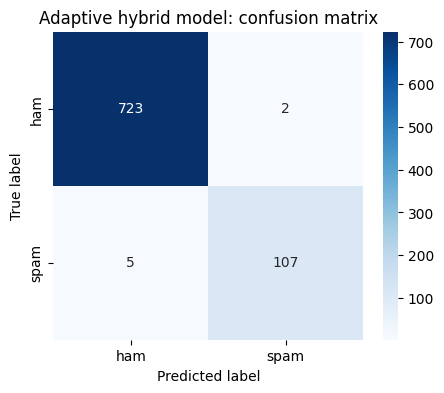

   very_short  contains_url  contains_negation      mean  count
0       False         False              False  0.727704    591
1       False         False               True  0.709650    116
4        True         False              False  0.770567    104
2       False          True              False  0.812381     16
3       False          True               True  0.806986      5
5        True         False               True  0.753730      5

Highest DistilBERT-gate messages:


/tmp/ipykernel_3307/2668553223.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  analysis_df["contains_negation"] = analysis_df["text"].str.contains(r"\b(not|no|never|n't)\b", case=False, regex=True)


,text,label,prediction,bert_gate
566,Bugis oso near wat... \n,0,0,0.983210
195,NEFT Transaction with reference number &lt;#&...,0,0,0.978361
292,Okie... Thanx...\n,0,0,0.975366
142,Is toshiba portege m100 gd?\n,0,0,0.973731
60,Its a big difference. &lt;#&gt; versus &lt;...,0,0,0.969548
458,Yup. Thk of u oso boring wat.\n,0,0,0.965524
235,S..antha num corrct dane\n,0,0,0.962548
822,Can you do online transaction?\n,0,0,0.959743
79,wiskey Brandy Rum Gin Beer Vodka Scotch Shampa...,0,0,0.955705
303,&lt;#&gt; w jetton ave if you forgot\n,0,0,0.954224



Lowest DistilBERT-gate messages:


,text,label,prediction,bert_gate
198,No screaming means shouting..\n,0,0,0.467659
509,Sad story of a Man - Last week was my b'day. M...,0,0,0.504187
122,Poor girl can't go one day lmao\n,0,0,0.504958
778,"As I entered my cabin my PA said, '' Happy B'd...",0,0,0.508622
341,Men like shorter ladies. Gaze up into his eyes.\n,0,0,0.509319
359,Ok ill tell the company\n,0,0,0.512415
576,Are u coming to the funeral home\n,0,0,0.513341
114,Holy living christ what is taking you so long\n,0,0,0.525717
479,Very strange. and are watching the 2nd one n...,0,0,0.533374
457,"I do know what u mean, is the king of not hav...",0,0,0.539177


In [17]:
print(classification_report(y_test, hybrid_pred, target_names=["ham", "spam"]))

cm = confusion_matrix(y_test, hybrid_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Adaptive hybrid model: confusion matrix")
plt.show()

analysis_df = test_df[["text", "label"]].copy()
analysis_df["prediction"] = hybrid_pred
analysis_df["bert_gate"] = test_gates
analysis_df["word_count"] = analysis_df["text"].str.split().str.len()
analysis_df["contains_url"] = analysis_df["text"].str.contains(r"http|www|\.com", case=False, regex=True)
analysis_df["very_short"] = analysis_df["word_count"] <= 5
analysis_df["contains_negation"] = analysis_df["text"].str.contains(r"\b(not|no|never|n't)\b", case=False, regex=True)

gate_summary = analysis_df.groupby(["very_short", "contains_url", "contains_negation"])["bert_gate"].agg(["mean", "count"]).reset_index()
print(gate_summary.sort_values("count", ascending=False).head(10))

print("\nHighest DistilBERT-gate messages:")
display(analysis_df.sort_values("bert_gate", ascending=False)[["text", "label", "prediction", "bert_gate"]].head(10))

print("\nLowest DistilBERT-gate messages:")
display(analysis_df.sort_values("bert_gate", ascending=True)[["text", "label", "prediction", "bert_gate"]].head(10))

## Save results and provenance

The following export cell is unchanged. Running it in a future reproduction overwrites the two CSV filenames in that reproduction directory. This reviewed notebook does not establish a new run. See README.md, CODE_PROVENANCE.md, THIRD_PARTY_NOTICES.md and ../audit/CLAIM_TRACEABILITY.md. Original notebook code history is unavailable. Conventional API use alone is not evidence of copying or originality.


In [18]:
results_df.to_csv("main_results.csv", index=False)
analysis_df.to_csv("adaptive_hybrid_test_analysis.csv", index=False)
print("Saved: main_results.csv and adaptive_hybrid_test_analysis.csv")
results_df

Saved: main_results.csv and adaptive_hybrid_test_analysis.csv


,model,accuracy,macro_f1,macro_precision,macro_recall,train_seconds
0,Frozen DistilBERT + Logistic Regression,0.992832,0.984654,0.981073,0.988313,0.250967
1,Simple concatenation + Logistic Regression,0.991637,0.982029,0.980229,0.983849,0.798694
2,Adaptive TF-IDF + GloVe + DistilBERT gate,0.991637,0.981754,0.987392,0.976299,29.830271
3,TF-IDF + Logistic Regression,0.985663,0.969076,0.969076,0.969076,0.087226
4,GloVe mean + Logistic Regression,0.949821,0.904379,0.866066,0.959711,0.076514


## References

[1] T. A. Almeida, J. M. Gómez Hidalgo, and A. Yamakami, ‘Contributions to the study of SMS spam filtering: new collection and results,’ Proceedings of the 11th ACM Symposium on Document Engineering, pp. 259–262, 2011. https://doi.org/10.1145/2034691.2034742

[2] G. Salton and C. Buckley, ‘Term-weighting approaches in automatic text retrieval,’ Information Processing & Management, vol. 24, no. 5, pp. 513–523, 1988. https://doi.org/10.1016/0306-4573(88)90021-0

[3] J. Pennington, R. Socher, and C. D. Manning, ‘GloVe: Global Vectors for Word Representation,’ Proceedings of EMNLP, pp. 1532–1543, 2014. https://doi.org/10.3115/v1/D14-1162

[4] V. Sanh, L. Debut, J. Chaumond, and T. Wolf, ‘DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter,’ arXiv:1910.01108, 2019. https://arxiv.org/abs/1910.01108

[5] S. Wang and C. D. Manning, ‘Baselines and Bigrams: Simple, Good Sentiment and Topic Classification,’ Proceedings of ACL, Volume 2: Short Papers, pp. 90–94, 2012. https://aclanthology.org/P12-2018/

[6] M. Sokolova and G. Lapalme, ‘A systematic analysis of performance measures for classification tasks,’ Information Processing & Management, vol. 45, no. 4, pp. 427–437, 2009. https://doi.org/10.1016/j.ipm.2009.03.002

[7] J. Arevalo, T. Solorio, M. Montes-y-Gómez, and F. A. González, ‘Gated Multimodal Units for Information Fusion,’ arXiv:1702.01992, 2017. https://arxiv.org/abs/1702.01992

[8] S. Jain and B. C. Wallace, ‘Attention is not Explanation,’ Proceedings of NAACL-HLT, Volume 1, pp. 3543–3556, 2019. https://doi.org/10.18653/v1/N19-1357

[9] S. Wiegreffe and Y. Pinter, ‘Attention is not not Explanation,’ Proceedings of EMNLP-IJCNLP, pp. 11–20, 2019. https://doi.org/10.18653/v1/D19-1002

[10] T. Almeida and J. Hidalgo, ‘SMS Spam Collection,’ UCI Machine Learning Repository, dataset, 2011. Current repository record accessed 27 September 2026. https://doi.org/10.24432/C5CC84

[11] UC Irvine / Hugging Face Datasets, ‘ucirvine/sms_spam,’ dataset card and viewer. Accessed 27 September 2026. https://huggingface.co/datasets/ucirvine/sms_spam

[12] Hugging Face / DistilBERT, ‘distilbert-base-uncased,’ model card. Accessed 27 September 2026. https://huggingface.co/distilbert/distilbert-base-uncased

[13] Stanford NLP Group, ‘GloVe: Global Vectors for Word Representation,’ pretrained-resource documentation. Accessed 27 September 2026. https://nlp.stanford.edu/projects/glove/

[14] F. D. M. A. Ali, S. M. Saide, R. Sousa-Silva, and H. Lopes Cardoso, ‘MOZ-Smishing: A Benchmark Dataset for Detecting Mobile Money Frauds,’ Proceedings of the Sixth Workshop on African Natural Language Processing, pp. 158–166, 2025. https://doi.org/10.18653/v1/2025.africanlp-1.23